In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
file_name = "2) Stock Prices Data Set.csv"
df = pd.read_csv(file_name)

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['symbol', 'date']).dropna()

df['return'] = df.groupby('symbol')['close'].pct_change()
df = df.dropna()

stock_features = df.groupby('symbol').agg(
    mean_return=('return', 'mean'),
    volatility=('return', 'std'),
    mean_volume=('volume', 'mean')
).dropna()

print(f"Total Unique Stocks Identified: {len(stock_features)}")
print("\nFirst 5 Stocks Profile Summary:")
print(stock_features.head())

Total Unique Stocks Identified: 505

First 5 Stocks Profile Summary:
        mean_return  volatility   mean_volume
symbol                                       
A          0.000306    0.015787  2.192206e+06
AAL        0.000965    0.022389  9.752269e+06
AAP        0.000096    0.019471  1.137898e+06
AAPL       0.000860    0.014309  4.515603e+07
ABBV       0.000753    0.016436  8.412653e+06


In [3]:
X = stock_features[['mean_return', 'volatility']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features Scaled and Normalized Successfully.")
print(f"Shape of Input Matrix: {X_scaled.shape}")

Features Scaled and Normalized Successfully.
Shape of Input Matrix: (505, 2)


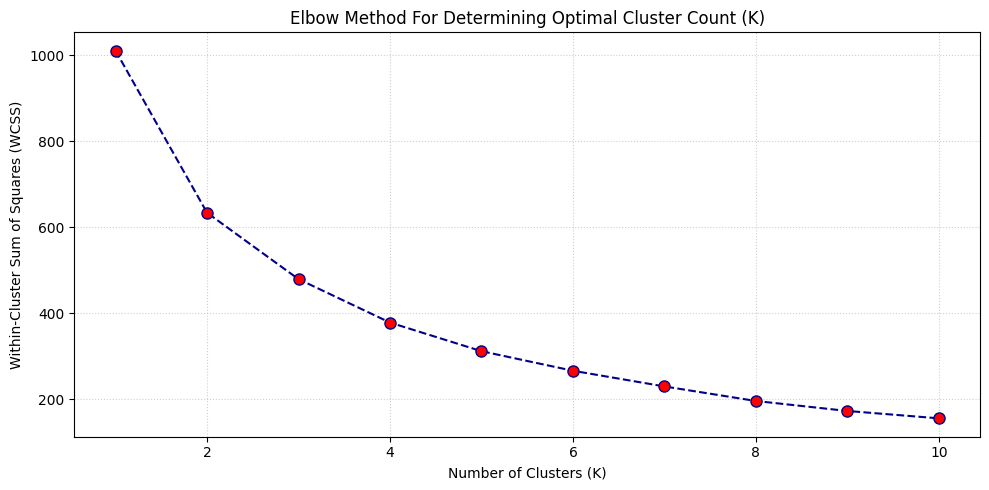

In [4]:
wcss = []
K_range = range(1, 11)

for i in K_range:
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(K_range, wcss, marker='o', linestyle='--', color='darkblue', markerfacecolor='red', markersize=8)
plt.title('Elbow Method For Determining Optimal Cluster Count (K)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('kmeans_elbow.png')
plt.show()

In [5]:
optimal_k = 4
kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
stock_features['cluster'] = kmeans_final.fit_predict(X_scaled)

print("Distribution of Stocks Across Clusters:")
print(stock_features['cluster'].value_counts())

Distribution of Stocks Across Clusters:
cluster
1    353
2     81
0     65
3      6
Name: count, dtype: int64


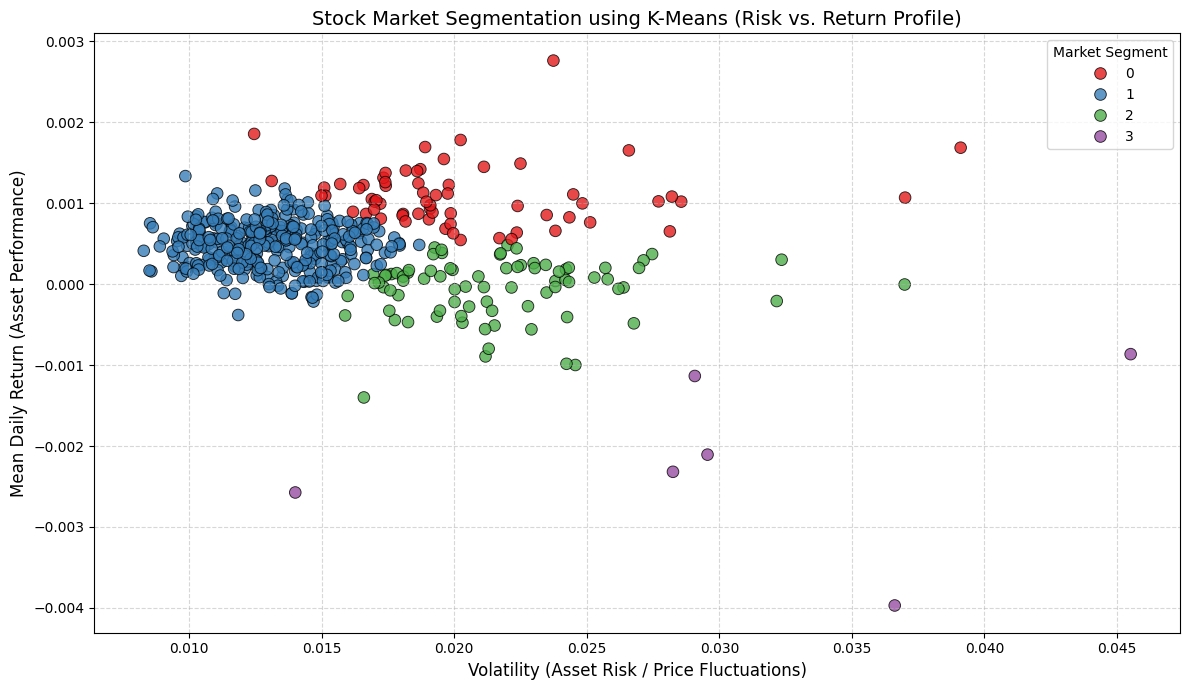

In [6]:
plt.figure(figsize=(12, 7))
sns.scatterplot(
    x='volatility', y='mean_return', hue='cluster',
    data=stock_features, palette='Set1', alpha=0.8, s=70, edgecolor='black'
)
plt.title('Stock Market Segmentation using K-Means (Risk vs. Return Profile)', fontsize=14)
plt.xlabel('Volatility (Asset Risk / Price Fluctuations)', fontsize=12)
plt.ylabel('Mean Daily Return (Asset Performance)', fontsize=12)
plt.legend(title='Market Segment', loc='best')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('stock_market_clusters.png')
plt.show()

In [7]:
cluster_analysis = stock_features.groupby('cluster').mean()
print("Financial Evaluation Matrix per Cluster (Centroids):\n")
print(cluster_analysis)

print("\n" + "="*50 + "\n")
print("Financial Segment Interpretations:\n")
for cluster_num in range(optimal_k):
    subset = stock_features[stock_features['cluster'] == cluster_num]
    sample_stocks = list(subset.index[:5])
    print(f"🔹 Cluster {cluster_num}: Contains {len(subset)} stocks. Sample tickers: {sample_stocks}")

Financial Evaluation Matrix per Cluster (Centroids):

         mean_return  volatility   mean_volume
cluster                                       
0           0.001095    0.020307  5.160642e+06
1           0.000480    0.013086  4.012773e+06
2          -0.000056    0.021608  4.285756e+06
3          -0.002161    0.030501  7.231794e+06


Financial Segment Interpretations:

🔹 Cluster 0: Contains 65 stocks. Sample tickers: ['AAL', 'ADBE', 'ADSK', 'AET', 'AKAM']
🔹 Cluster 1: Contains 353 stocks. Sample tickers: ['A', 'AAPL', 'ABBV', 'ABC', 'ABT']
🔹 Cluster 2: Contains 81 stocks. Sample tickers: ['AAP', 'ADS', 'AES', 'AGN', 'ALXN']
🔹 Cluster 3: Contains 6 stocks. Sample tickers: ['APTV', 'BHGE', 'CHK', 'EVHC', 'RRC']


In [8]:
print("Statistical Boundaries per Market Segment:\n")
boundaries = stock_features.groupby('cluster').agg({
    'mean_return': ['min', 'max'],
    'volatility': ['min', 'max'],
    'mean_volume': ['min', 'max']
})
print(boundaries)

print("\n" + "="*50 + "\n")
print("Full Ticker Distribution Preview:\n")
for cluster_num in range(optimal_k):
    all_stocks = list(stock_features[stock_features['cluster'] == cluster_num].index)
    print(f"📦 Cluster {cluster_num} Complete Asset List ({len(all_stocks)} Stocks):")
    print(", ".join(all_stocks))
    print("-" * 30)

Statistical Boundaries per Market Segment:

        mean_return           volatility             mean_volume              
                min       max        min       max           min           max
cluster                                                                       
0          0.000545  0.002760   0.012449  0.039102  3.329955e+05  3.330215e+07
1         -0.000382  0.001334   0.008284  0.018677  1.719373e+05  8.930340e+07
2         -0.001400  0.000481   0.015882  0.036989  4.722067e+05  2.563629e+07
3         -0.003969 -0.000865   0.014001  0.045515  1.928500e+06  2.790612e+07


Full Ticker Distribution Preview:

📦 Cluster 0 Complete Asset List (65 Stocks):
AAL, ADBE, ADSK, AET, AKAM, ALB, ALGN, ALK, AMAT, AMD, AMZN, ANDV, ATVI, AVGO, AYI, BBY, CFG, CHTR, CNC, CRM, CSX, CXO, DAL, DHI, DXC, EA, ETFC, EW, EXPE, FB, GPN, HII, HPQ, HUM, IDXX, ILMN, INCY, ISRG, LNT, LRCX, LUV, MGM, MLM, MNST, MPC, MU, NCLH, NEM, NFLX, NFX, NVDA, PYPL, RCL, REGN, RHT, SCHW, STZ, SWKS, TSN, UAL, 